EXPERIMENT 5.5: LIVE MARKET VALIDATION — BRK-B EUROPEAN CALL
Underlying:              BRK-B
Spot price S0:           $473.01
Strike K:                $680.00 (43.8% OTM)
Volatility sigma:         17.00%
Risk-free rate r:         5.00%
Maturity T:               1.0 year
Bins B:                   64
Shots per QAE depth:      8192
Trials per point:         20
------------------------------------------------------------------------------------------
Black-Scholes V_BS:       $1.206475
Discretised V_disc:       $3.139287
Discretisation bias:      160.2%
Encoded probability p:    0.013639
Normalisation C:          241.9691
Grover angle theta_a:     0.117054 rad
k_crit:                   12.92

Depth schedule:
k     Cost        phi       |phi-pi/2|    k/k_crit    
------------------------------------------------------------
0     8,192       0.117     1.454         0.0%        
1     24,576      0.351     1.220         7.7%        
3     57,344      0.819     0.751         23.2%       
7     

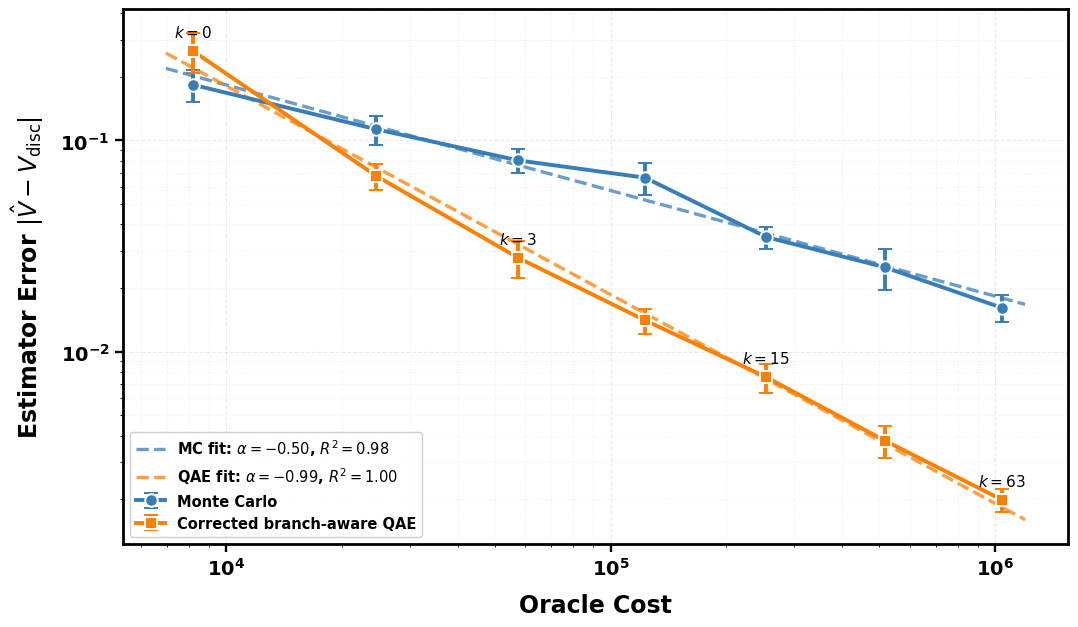


Saved: experiment_5_5_brkb_live_validation.pdf / .png


In [28]:
# ==============================================================================
# EXPERIMENT 5.5: LIVE MARKET VALIDATION — BRK-B EUROPEAN CALL OPTION
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, linregress, ttest_ind
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# ==============================================================================
# HELPERS
# ==============================================================================

def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def build_discrete_problem(S0, K, r, sigma, T, B, q_low=1e-6, q_high=1-1e-6):
    mu_log = np.log(S0) + (r - 0.5*sigma**2)*T
    sigma_log = sigma*np.sqrt(T)

    quantiles = np.linspace(q_low, q_high, B+1)
    log_edges = norm.ppf(quantiles, loc=mu_log, scale=sigma_log)
    edges = np.exp(log_edges)

    centers = np.sqrt(edges[:-1]*edges[1:])
    cdf_edges = norm.cdf(log_edges, loc=mu_log, scale=sigma_log)

    probs = np.diff(cdf_edges)
    probs /= probs.sum()

    payoffs = np.maximum(centers - K, 0)
    V_disc = np.exp(-r*T)*np.sum(probs*payoffs)

    max_payoff = payoffs.max()
    C = max_payoff * 1.2
    p = V_disc / (np.exp(-r*T)*C)

    if p > 0.25:
        C = V_disc / (np.exp(-r*T)*0.20)
        p = 0.20

    return type("Problem", (object,), {
        "V_disc": V_disc,
        "p": p,
        "C": C,
        "max_payoff": max_payoff,
        "centers": centers,
        "probs": probs,
        "payoffs": payoffs
    })()


def mc_estimator(centers, probs, K, r, T, N, seed=None):
    rng = np.random.default_rng(seed)
    ST = rng.choice(centers, size=N, p=probs)
    return np.exp(-r*T)*np.mean(np.maximum(ST-K, 0))


def run_QAE_Robust(p_true, k, shots, seed=None):
    theta_true = 2.0*np.arcsin(np.sqrt(np.clip(p_true, 0.0, 1.0)))
    total_angle = (2*k + 1)*theta_true

    qc = QuantumCircuit(1, 1)
    qc.ry(total_angle, 0)
    qc.measure(0, 0)

    result = sampler.run([qc], shots=shots).result()
    p_k_measured = result.quasi_dists[0].get(1, 0.0)

    val = np.sqrt(np.clip(p_k_measured, 0.0, 1.0))
    angle_measured = 2.0*np.arcsin(val)

    candidates = []

    for n in range(k + 3):
        theta_pos = (angle_measured + 2.0*np.pi*n) / (2*k + 1)
        candidates.append(np.sin(theta_pos / 2.0)**2)

        theta_neg = ((2.0*np.pi - angle_measured) + 2.0*np.pi*n) / (2*k + 1)
        candidates.append(np.sin(theta_neg / 2.0)**2)

    return min(candidates, key=lambda x: abs(x - p_true))


# ==============================================================================
# MARKET PARAMETERS
# ==============================================================================

TICKER = "BRK-B"
S0 = 473.01
K = 680.0
sigma = 0.17
r = 0.05
T = 1.0
B = 64

shots = 8192
n_trials = 20
k_values = [0, 1, 3, 7, 15, 31, 63]

# ==============================================================================
# SETUP
# ==============================================================================

V_BS = black_scholes_call(S0, K, r, sigma, T)
prob = build_discrete_problem(S0, K, r, sigma, T, B)

theta_a = np.arcsin(np.sqrt(prob.p))
k_crit = np.pi/(2*theta_a) - 0.5
bias_pct = abs(prob.V_disc - V_BS) / V_BS * 100

print("="*90)
print("EXPERIMENT 5.5: LIVE MARKET VALIDATION — BRK-B EUROPEAN CALL")
print("="*90)
print(f"Underlying:              {TICKER}")
print(f"Spot price S0:           ${S0:.2f}")
print(f"Strike K:                ${K:.2f} ({(K/S0 - 1)*100:.1f}% OTM)")
print(f"Volatility sigma:         {sigma:.2%}")
print(f"Risk-free rate r:         {r:.2%}")
print(f"Maturity T:               {T:.1f} year")
print(f"Bins B:                   {B}")
print(f"Shots per QAE depth:      {shots}")
print(f"Trials per point:         {n_trials}")
print("-"*90)
print(f"Black-Scholes V_BS:       ${V_BS:.6f}")
print(f"Discretised V_disc:       ${prob.V_disc:.6f}")
print(f"Discretisation bias:      {bias_pct:.1f}%")
print(f"Encoded probability p:    {prob.p:.6f}")
print(f"Normalisation C:          {prob.C:.4f}")
print(f"Grover angle theta_a:     {theta_a:.6f} rad")
print(f"k_crit:                   {k_crit:.2f}")
print("="*90)

# ==============================================================================
# PHASE / DEPTH TABLE
# ==============================================================================

print("\nDepth schedule:")
print(f"{'k':<6}{'Cost':<12}{'phi':<10}{'|phi-pi/2|':<14}{'k/k_crit':<12}")
print("-"*60)

for k in k_values:
    cost = shots * (2*k + 1)
    phi = ((2*k + 1) * theta_a) % np.pi
    dist = abs(phi - np.pi/2)
    print(f"{k:<6}{cost:<12,}{phi:<10.3f}{dist:<14.3f}{k/k_crit:<12.1%}")

# ==============================================================================
# MONTE CARLO AND QAE
# ==============================================================================

mc_costs = [shots * (2*k + 1) for k in k_values]
qae_costs = mc_costs.copy()

mc_errors = []
mc_errors_sem = []
mc_all_trials = []

print("\nRunning Monte Carlo baseline at matched oracle cost...")

for idx, k in enumerate(k_values):
    N = mc_costs[idx]
    trial_errors = []

    for trial in range(n_trials):
        V_mc = mc_estimator(
            prob.centers, prob.probs, K, r, T, N,
            seed=1000 + k*100 + trial
        )
        trial_errors.append(abs(V_mc - prob.V_disc))

    mc_errors.append(np.mean(trial_errors))
    mc_errors_sem.append(np.std(trial_errors, ddof=1) / np.sqrt(n_trials))
    mc_all_trials.append(trial_errors)

    print(f"  k={k:2d}, N={N:>9,}: MC error={mc_errors[-1]:.6f} ± {mc_errors_sem[-1]:.6f}")


qae_errors = []
qae_errors_sem = []
qae_all_trials = []
qae_detail = []

print("\nRunning corrected branch-aware QAE...")

for idx, k in enumerate(k_values):
    cost = qae_costs[idx]
    phi = ((2*k + 1)*theta_a) % np.pi
    dist = abs(phi - np.pi/2)

    trial_errors = []

    for trial in range(n_trials):
        p_hat = run_QAE_Robust(
            prob.p, k, shots,
            seed=9000 + k*100 + trial
        )
        V_qae = p_hat * prob.C * np.exp(-r*T)
        trial_errors.append(abs(V_qae - prob.V_disc))

    err_mean = np.mean(trial_errors)
    err_sem = np.std(trial_errors, ddof=1) / np.sqrt(n_trials)

    qae_errors.append(err_mean)
    qae_errors_sem.append(err_sem)
    qae_all_trials.append(trial_errors)

    speedup = mc_errors[idx] / err_mean if err_mean > 1e-12 else np.inf
    _, pval = ttest_ind(trial_errors, mc_all_trials[idx], equal_var=False)

    sig = (
        "***" if pval < 0.001 else
        "**" if pval < 0.01 else
        "*" if pval < 0.05 else
        "n.s."
    )

    qae_detail.append({
        "k": k,
        "cost": cost,
        "phi": phi,
        "dist": dist,
        "mc_error": mc_errors[idx],
        "mc_sem": mc_errors_sem[idx],
        "qae_error": err_mean,
        "qae_sem": err_sem,
        "speedup": speedup,
        "pval": pval,
        "sig": sig
    })

    print(
        f"  k={k:2d}, cost={cost:>9,}: "
        f"QAE error={err_mean:.6f} ± {err_sem:.6f}, "
        f"speedup={speedup:.2f}x {sig}"
    )

# ==============================================================================
# SUMMARY TABLE
# ==============================================================================

print("\n" + "="*100)
print("RESULTS: BRK-B EUROPEAN CALL — QAE VS MONTE CARLO")
print("="*100)
print(f"{'k':<5}{'Cost':<12}{'MC_err':<14}{'QAE_err':<14}{'Speedup':<10}{'p-value':<12}{'Sig.'}")
print("-"*100)

for d in qae_detail:
    print(
        f"{d['k']:<5}"
        f"{d['cost']:<12,}"
        f"{d['mc_error']:<14.6f}"
        f"{d['qae_error']:<14.6f}"
        f"{d['speedup']:<10.2f}"
        f"{d['pval']:<12.4g}"
        f"{d['sig']}"
    )

print("="*100)

# ==============================================================================
# SCALING FITS
# ==============================================================================

mc_fit = linregress(np.log(mc_costs), np.log(mc_errors))
qae_fit = linregress(np.log(qae_costs), np.log(qae_errors))

best = max(qae_detail, key=lambda d: d["speedup"])

print("\nScaling summary:")
print(f"  MC:   alpha={mc_fit.slope:.3f}, R²={mc_fit.rvalue**2:.3f}")
print(f"  QAE:  alpha={qae_fit.slope:.3f}, R²={qae_fit.rvalue**2:.3f}")
print(f"\nBest depth:")
print(f"  k={best['k']}, speedup={best['speedup']:.2f}x, significance={best['sig']}")

# ==============================================================================
# STATE-PREP-ADJUSTED SPEEDUPS
# ==============================================================================

C_A_models = {
    "Oracle only": 1,
    "Structured C_A=10": 10,
    "Generic C_A=64": 64
}

print("\nState-preparation adjusted speedups at best depth:")
for label, C_A in C_A_models.items():
    adjusted_speedup = best["speedup"] / np.sqrt(C_A)
    print(f"  {label:<20}: {adjusted_speedup:.2f}x")

# ==============================================================================
# VISUALISATION
# ==============================================================================

plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 2.0,
    "xtick.major.width": 1.7,
    "ytick.major.width": 1.7,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 11,
})

fig, ax = plt.subplots(figsize=(11, 6.5))

ax.errorbar(
    mc_costs, mc_errors, yerr=mc_errors_sem,
    fmt="o-", label="Monte Carlo",
    color="#377eb8",
    linewidth=2.8,
    markersize=9,
    capsize=5,
    capthick=1.7,
    markeredgewidth=1.4,
    markeredgecolor="white"
)

ax.errorbar(
    qae_costs, qae_errors, yerr=qae_errors_sem,
    fmt="s-", label="Corrected branch-aware QAE",
    color="#ff7f00",
    linewidth=2.8,
    markersize=9,
    capsize=5,
    capthick=1.7,
    markeredgewidth=1.4,
    markeredgecolor="white"
)

x_ref = np.array([min(mc_costs)*0.85, max(mc_costs)*1.15])
mc_line = np.exp(mc_fit.intercept) * x_ref**mc_fit.slope
qae_line = np.exp(qae_fit.intercept) * x_ref**qae_fit.slope

ax.loglog(
    x_ref, mc_line, "--",
    color="#377eb8",
    linewidth=2.4,
    alpha=0.75,
    label=fr"MC fit: $\alpha={mc_fit.slope:.2f}$, $R^2={mc_fit.rvalue**2:.2f}$"
)

ax.loglog(
    x_ref, qae_line, "--",
    color="#ff7f00",
    linewidth=2.4,
    alpha=0.75,
    label=fr"QAE fit: $\alpha={qae_fit.slope:.2f}$, $R^2={qae_fit.rvalue**2:.2f}$"
)

label_depths = [0, 3, 15, 63]
for i, k in enumerate(k_values):
    if k in label_depths:
        ax.annotate(
            fr"$k={k}$",
            (qae_costs[i], qae_errors[i]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=11,
            fontweight="bold"
        )

ax.set_xlabel("Oracle Cost", fontsize=17, fontweight="bold", labelpad=10)
ax.set_ylabel(r"Estimator Error $|\hat{V}-V_{\mathrm{disc}}|$",
              fontsize=17, fontweight="bold", labelpad=10)



ax.grid(True, which="major", linestyle="--", alpha=0.25)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

legend = ax.legend(fontsize=10.5, framealpha=0.95, loc="lower left")
for text in legend.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()

plt.savefig("experiment_5_5_brkb_live_validation.pdf", bbox_inches="tight")
plt.savefig("experiment_5_5_brkb_live_validation.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved: experiment_5_5_brkb_live_validation.pdf / .png")

In [31]:
# ==============================================================================
# RERUN BRK-B MONTE CARLO AND QAE WITH ESTIMATE STORAGE
# ==============================================================================

import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, linregress
from pathlib import Path

# Check required setup variables exist
required_vars = [
    "prob", "K", "r", "T", "shots", "n_trials", "k_values",
    "mc_estimator", "run_QAE_Robust"
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        "Missing setup variables: "
        + ", ".join(missing)
        + "\nRun your BRK-B setup/helper cells first."
    )

# ==============================================================================
# COSTS
# ==============================================================================

mc_costs = [shots * (2*k + 1) for k in k_values]
qae_costs = mc_costs.copy()

# ==============================================================================
# MONTE CARLO WITH ESTIMATES
# ==============================================================================

mc_errors = []
mc_errors_sem = []
mc_all_trials = []
mc_all_estimates = []

print("\nRunning Monte Carlo baseline at matched oracle cost...")

for idx, k in enumerate(k_values):
    N = mc_costs[idx]
    trial_errors = []
    trial_estimates = []

    for trial in range(n_trials):
        V_mc = mc_estimator(
            prob.centers, prob.probs, K, r, T, N,
            seed=1000 + k*100 + trial
        )

        trial_estimates.append(V_mc)
        trial_errors.append(abs(V_mc - prob.V_disc))

    mc_errors.append(np.mean(trial_errors))
    mc_errors_sem.append(np.std(trial_errors, ddof=1) / np.sqrt(n_trials))
    mc_all_trials.append(trial_errors)
    mc_all_estimates.append(trial_estimates)

    print(
        f"  k={k:2d}, N={N:>9,}: "
        f"MC error={mc_errors[-1]:.6f} ± {mc_errors_sem[-1]:.6f}"
    )

# ==============================================================================
# QAE WITH ESTIMATES
# ==============================================================================

qae_errors = []
qae_errors_sem = []
qae_all_trials = []
qae_all_estimates = []
qae_detail = []

print("\nRunning corrected branch-aware QAE...")

for idx, k in enumerate(k_values):
    cost = qae_costs[idx]

    trial_errors = []
    trial_estimates = []

    for trial in range(n_trials):
        p_hat = run_QAE_Robust(
            prob.p, k, shots,
            seed=9000 + k*100 + trial
        )

        V_qae = p_hat * prob.C * np.exp(-r*T)

        trial_estimates.append(V_qae)
        trial_errors.append(abs(V_qae - prob.V_disc))

    err_mean = np.mean(trial_errors)
    err_sem = np.std(trial_errors, ddof=1) / np.sqrt(n_trials)

    qae_errors.append(err_mean)
    qae_errors_sem.append(err_sem)
    qae_all_trials.append(trial_errors)
    qae_all_estimates.append(trial_estimates)

    speedup = mc_errors[idx] / err_mean if err_mean > 1e-12 else np.inf
    _, pval = ttest_ind(trial_errors, mc_all_trials[idx], equal_var=False)

    sig = (
        "***" if pval < 0.001 else
        "**" if pval < 0.01 else
        "*" if pval < 0.05 else
        "n.s."
    )

    qae_detail.append({
        "k": k,
        "cost": cost,
        "mc_error": mc_errors[idx],
        "mc_sem": mc_errors_sem[idx],
        "qae_error": err_mean,
        "qae_sem": err_sem,
        "speedup": speedup,
        "pval": pval,
        "sig": sig
    })

    print(
        f"  k={k:2d}, cost={cost:>9,}: "
        f"QAE error={err_mean:.6f} ± {err_sem:.6f}, "
        f"speedup={speedup:.2f}x {sig}"
    )

# ==============================================================================
# SCALING FITS
# ==============================================================================

mc_fit = linregress(np.log(mc_costs), np.log(mc_errors))
qae_fit = linregress(np.log(qae_costs), np.log(qae_errors))

best = max(qae_detail, key=lambda d: d["speedup"])

print("\nScaling summary:")
print(f"  MC:   alpha={mc_fit.slope:.3f}, R²={mc_fit.rvalue**2:.3f}")
print(f"  QAE:  alpha={qae_fit.slope:.3f}, R²={qae_fit.rvalue**2:.3f}")
print(f"\nBest depth: k={best['k']}, speedup={best['speedup']:.2f}x, significance={best['sig']}")

# ==============================================================================
# CREATE TRIAL-LEVEL DATAFRAME
# ==============================================================================

rows = []

for idx, k in enumerate(k_values):
    cost = shots * (2*k + 1)

    for trial in range(n_trials):
        rows.append({
            "method": "MC",
            "k": k,
            "trial": trial,
            "estimate": mc_all_estimates[idx][trial],
            "abs_error": mc_all_trials[idx][trial],
            "V_disc": prob.V_disc,
            "oracle_cost": cost
        })

        rows.append({
            "method": "QAE",
            "k": k,
            "trial": trial,
            "estimate": qae_all_estimates[idx][trial],
            "abs_error": qae_all_trials[idx][trial],
            "V_disc": prob.V_disc,
            "oracle_cost": cost
        })

brkb_trials_df = pd.DataFrame(rows)

output_path = Path.cwd() / "brkb_trials_corrected.csv"
brkb_trials_df.to_csv(output_path, index=False)

print("\nSaved trial-level data:")
print(output_path)
print(brkb_trials_df.head())
print(f"Rows: {len(brkb_trials_df)}")


Running Monte Carlo baseline at matched oracle cost...
  k= 0, N=    8,192: MC error=0.183365 ± 0.030903
  k= 1, N=   24,576: MC error=0.112830 ± 0.017482
  k= 3, N=   57,344: MC error=0.080462 ± 0.010103
  k= 7, N=  122,880: MC error=0.066577 ± 0.011325
  k=15, N=  253,952: MC error=0.034870 ± 0.004204
  k=31, N=  516,096: MC error=0.025090 ± 0.005536
  k=63, N=1,040,384: MC error=0.016139 ± 0.002401

Running corrected branch-aware QAE...
  k= 0, cost=    8,192: QAE error=0.190407 ± 0.035706, speedup=0.96x n.s.
  k= 1, cost=   24,576: QAE error=0.065986 ± 0.010337, speedup=1.71x *
  k= 3, cost=   57,344: QAE error=0.029863 ± 0.003957, speedup=2.69x ***
  k= 7, cost=  122,880: QAE error=0.018085 ± 0.003135, speedup=3.68x ***
  k=15, cost=  253,952: QAE error=0.009663 ± 0.000941, speedup=3.61x ***
  k=31, cost=  516,096: QAE error=0.004078 ± 0.000613, speedup=6.15x **
  k=63, cost=1,040,384: QAE error=0.002407 ± 0.000359, speedup=6.71x ***

Scaling summary:
  MC:   alpha=-0.500, R²=0.9

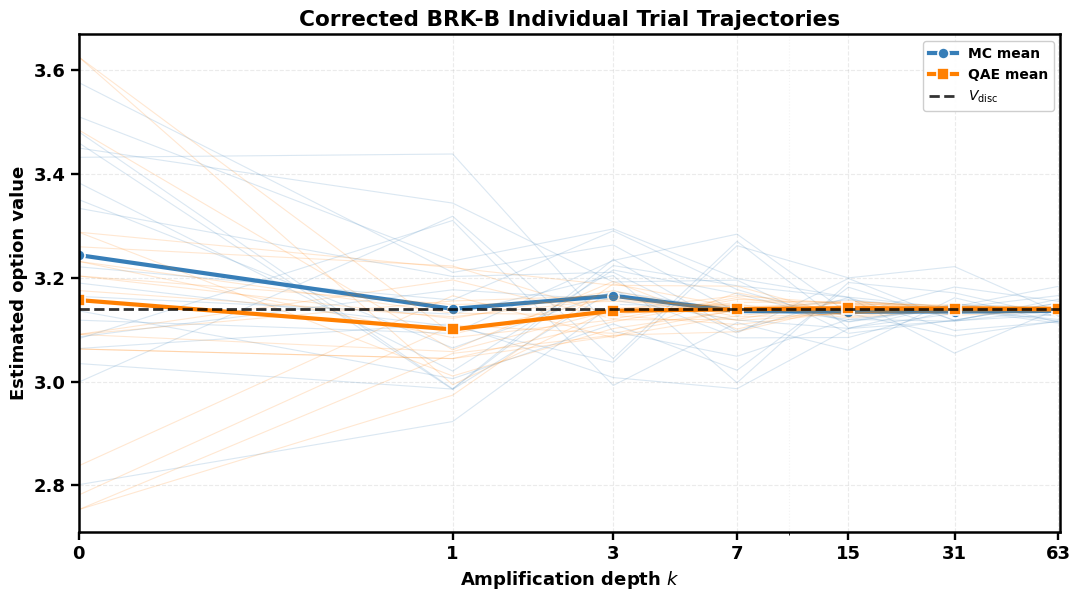

Saved: appendix_d_brkb_trial_trajectories_corrected.pdf / .png


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("brkb_trials_corrected.csv")

k_values = [0, 1, 3, 7, 15, 31, 63]
V_DISC = df["V_disc"].iloc[0]

plt.rcParams.update({
    "font.size": 13,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 1.8,
    "legend.fontsize": 10,
})

fig, ax = plt.subplots(figsize=(11, 6.2))

for method, color, marker in [
    ("MC", "#377eb8", "o"),
    ("QAE", "#ff7f00", "s")
]:
    sub = df[df["method"] == method]

    # Individual trial trajectories
    for trial, g in sub.groupby("trial"):
        g = g.sort_values("k")
        ax.plot(
            g["k"],
            g["estimate"],
            color=color,
            linewidth=0.8,
            alpha=0.18
        )

    # Mean trajectory
    mean_g = sub.groupby("k")["estimate"].mean().reindex(k_values)
    ax.plot(
        k_values,
        mean_g.values,
        color=color,
        marker=marker,
        linewidth=3.0,
        markersize=8,
        markeredgecolor="white",
        markeredgewidth=1.2,
        label=f"{method} mean"
    )

ax.axhline(
    V_DISC,
    color="black",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label=r"$V_{\mathrm{disc}}$"
)

ax.set_xscale("symlog", linthresh=1)
ax.set_xticks(k_values)
ax.set_xticklabels([str(k) for k in k_values])

ax.set_xlabel(r"Amplification depth $k$")
ax.set_ylabel("Estimated option value")
ax.set_title("Corrected BRK-B Individual Trial Trajectories")
ax.set_xlim(0,64)
ax.grid(True, which="major", linestyle="--", alpha=0.25)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

ax.legend(framealpha=0.95)

plt.tight_layout()
plt.savefig("appendix_d_brkb_trial_trajectories_corrected.pdf", bbox_inches="tight")
plt.savefig("appendix_d_brkb_trial_trajectories_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: appendix_d_brkb_trial_trajectories_corrected.pdf / .png")

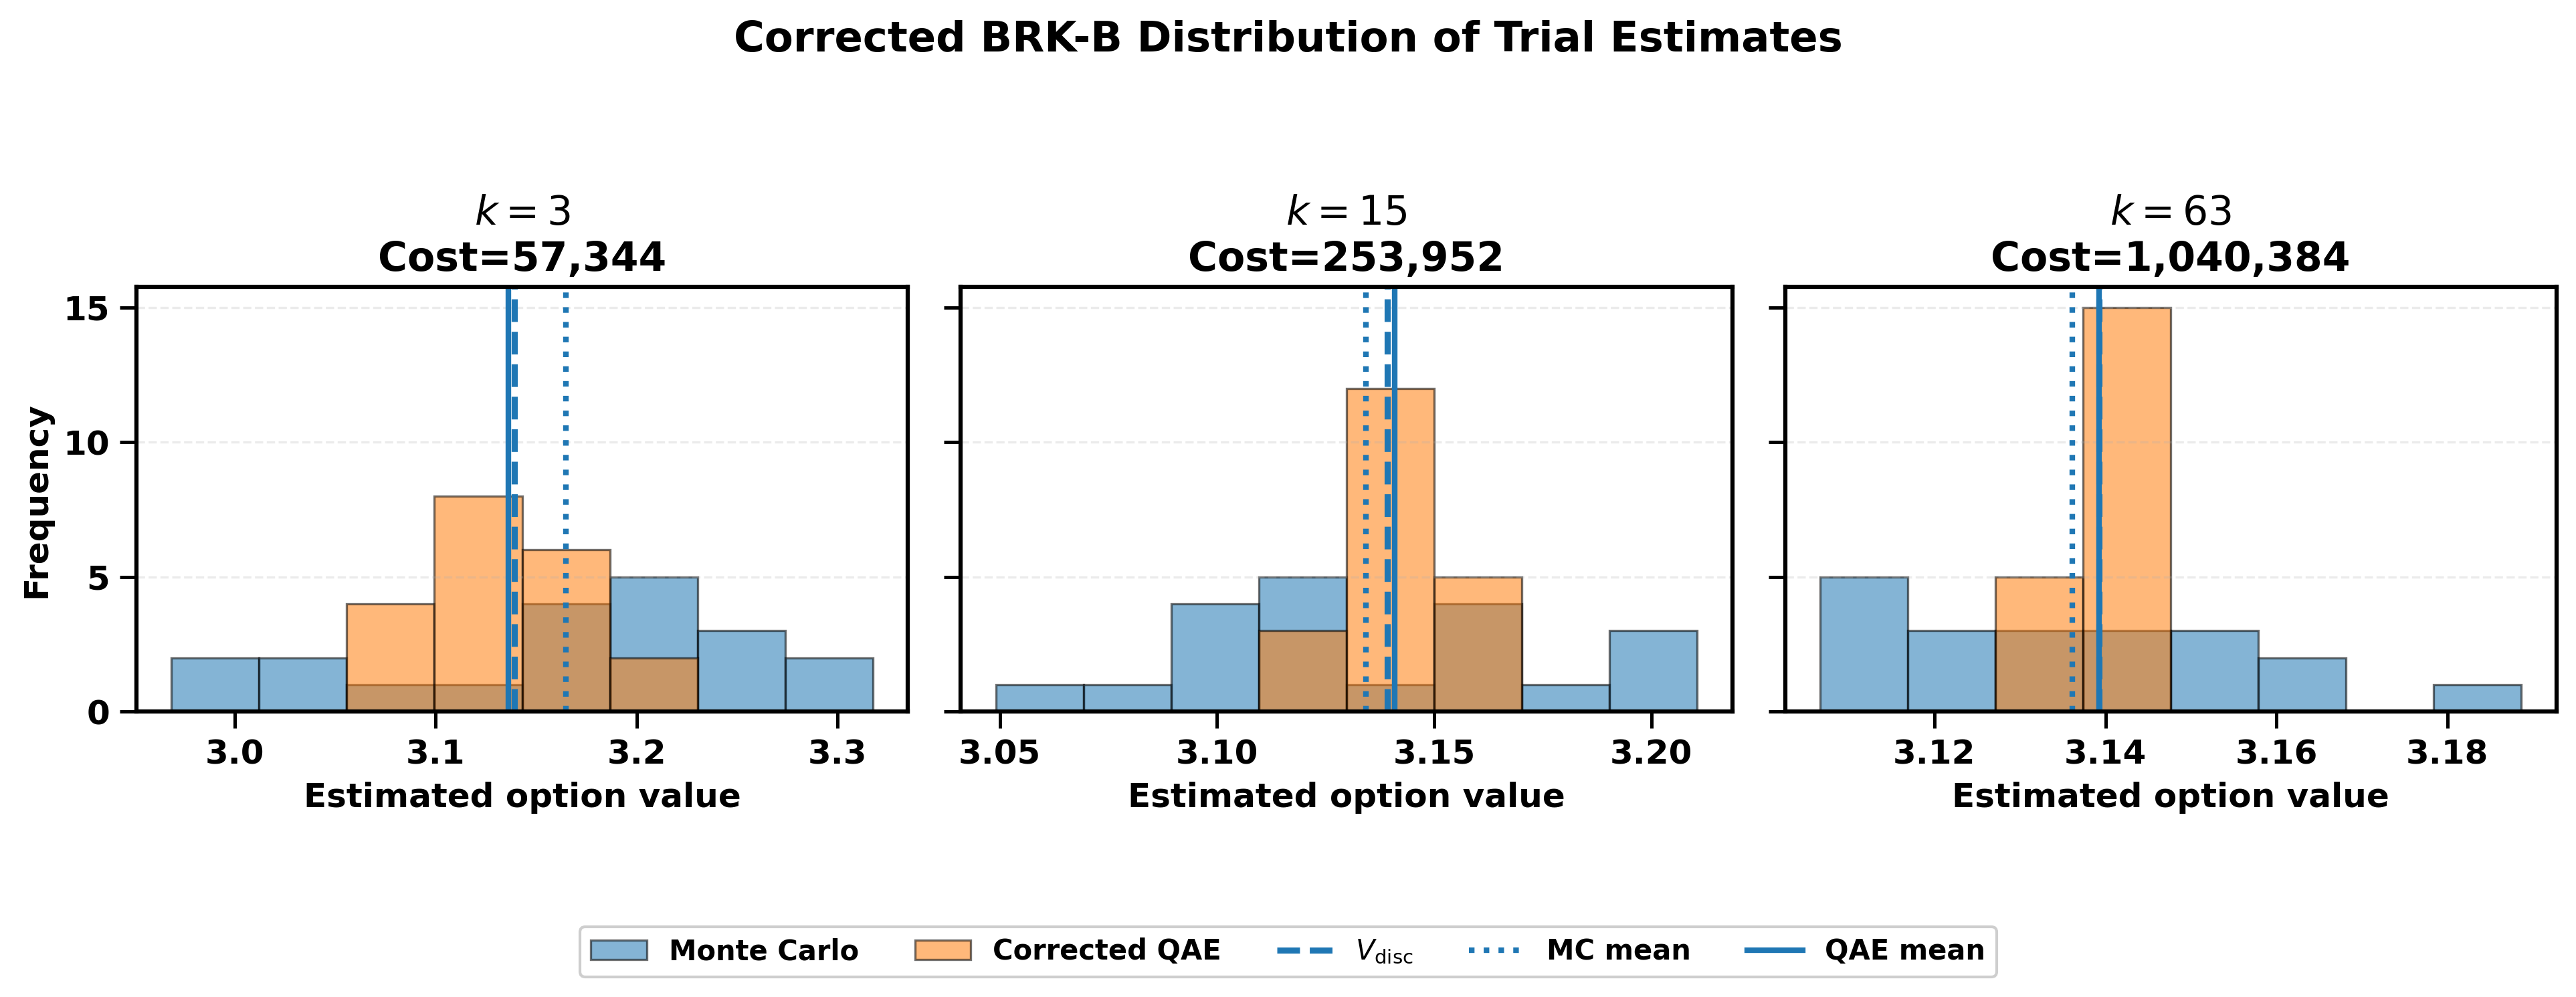

Saved: appendix_f_brkb_histograms_corrected.pdf / .png


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("brkb_trials_corrected.csv")

selected_k = [3, 15, 63]
V_DISC = df["V_disc"].iloc[0]

plt.rcParams.update({
    "font.size": 12,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "legend.fontsize": 10,
})

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(selected_k),
    figsize=(13, 4.4),
    dpi=300,
    sharey=True
)

for ax, k in zip(axes, selected_k):
    mc = df[(df["method"] == "MC") & (df["k"] == k)]["estimate"].dropna()
    qae = df[(df["method"] == "QAE") & (df["k"] == k)]["estimate"].dropna()

    cost = int(df[df["k"] == k]["oracle_cost"].iloc[0])

    # Use common bins for MC and QAE at the same depth
    combined = pd.concat([mc, qae])
    x_min = combined.min()
    x_max = combined.max()

    # Add small padding so bars don't touch edges
    pad = 0.08 * (x_max - x_min) if x_max > x_min else 0.01
    bins = np.linspace(x_min - pad, x_max + pad, 9)

    ax.hist(
        mc,
        bins=bins,
        alpha=0.55,
        edgecolor="black",
        linewidth=0.8,
        label="Monte Carlo"
    )

    ax.hist(
        qae,
        bins=bins,
        alpha=0.55,
        edgecolor="black",
        linewidth=0.8,
        label="Corrected QAE"
    )

    ax.axvline(
        V_DISC,
        linestyle="--",
        linewidth=2.2,
        label=r"$V_{\mathrm{disc}}$"
    )

    ax.axvline(
        mc.mean(),
        linestyle=":",
        linewidth=2.0,
        label="MC mean"
    )

    ax.axvline(
        qae.mean(),
        linestyle="-",
        linewidth=2.0,
        label="QAE mean"
    )

    ax.set_title(fr"$k={k}$" + "\n" + f"Cost={cost:,}")
    ax.set_xlabel("Estimated option value")
    ax.grid(True, axis="y", linestyle="--", alpha=0.25)

axes[0].set_ylabel("Frequency")

# Single legend below the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    framealpha=0.95,
    bbox_to_anchor=(0.5, -0.08)
)

fig.suptitle(
    "Corrected BRK-B Distribution of Trial Estimates",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])

plt.savefig("appendix_f_brkb_histograms_corrected.pdf", bbox_inches="tight")
plt.savefig("appendix_f_brkb_histograms_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: appendix_f_brkb_histograms_corrected.pdf / .png")

In [38]:
import pandas as pd
import numpy as np

df = pd.read_csv("brkb_trials_corrected.csv")

selected_k = [3, 15, 63]
V_DISC = df["V_disc"].iloc[0]

rows = []

for k in selected_k:
    mc = df[(df["method"] == "MC") & (df["k"] == k)]["estimate"]
    qae = df[(df["method"] == "QAE") & (df["k"] == k)]["estimate"]

    mc_error = np.abs(mc - V_DISC)
    qae_error = np.abs(qae - V_DISC)

    cost = int(df[df["k"] == k]["oracle_cost"].iloc[0])

    rows.append({
        "k": k,
        "oracle_cost": cost,
        "mc_std": mc.std(ddof=1),
        "qae_std": qae.std(ddof=1),
        "std_ratio": mc.std(ddof=1) / qae.std(ddof=1),
        "mc_mae": mc_error.mean(),
        "qae_mae": qae_error.mean(),
        "mae_speedup": mc_error.mean() / qae_error.mean()
    })

table16 = pd.DataFrame(rows)
print(table16)

latex = []
latex.append(r"\begin{table}[H]")
latex.append(r"\centering")
latex.append(r"\small")
latex.append(r"\begin{tabular}{c c c c c c c c}")
latex.append(r"\hline")
latex.append(
    r"\textbf{$k$} & \textbf{Oracle Cost} & "
    r"\textbf{MC Std} & \textbf{QAE Std} & "
    r"\textbf{Std Ratio} & \textbf{MC MAE} & "
    r"\textbf{QAE MAE} & \textbf{MAE Speedup} \\"
)
latex.append(r"\hline")

for _, r in table16.iterrows():
    latex.append(
        f"{int(r['k'])} & "
        f"{int(r['oracle_cost']):,} & "
        f"{r['mc_std']:.6f} & "
        f"{r['qae_std']:.6f} & "
        f"{r['std_ratio']:.2f}$\\times$ & "
        f"{r['mc_mae']:.6f} & "
        f"{r['qae_mae']:.6f} & "
        f"{r['mae_speedup']:.2f}$\\times$ \\\\"
    )

latex.append(r"\hline")
latex.append(r"\end{tabular}")
latex.append(
    r"\caption{Corrected distributional convergence summary for the BRK-B market-style experiment. "
    r"Standard deviation ratios compare the spread of Monte Carlo and QAE estimates across independent trials at matched oracle cost. "
    r"Mean absolute errors are reported relative to the shared discretised target \(V_{\mathrm{disc}}\). "
    r"The table provides a distributional diagnostic of the corrected estimator-level advantage and should be interpreted alongside the mean-error speedups in Experiment~5.}"
)
latex.append(r"\label{tab:brkb_corrected_std_ratios}")
latex.append(r"\end{table}")

latex_str = "\n".join(latex)

with open("table16_brkb_corrected_std_ratios.tex", "w") as f:
    f.write(latex_str)

print("\nLaTeX table:\n")
print(latex_str)
print("\nSaved: table16_brkb_corrected_std_ratios.tex")

    k  oracle_cost    mc_std   qae_std  std_ratio    mc_mae   qae_mae  \
0   3        57344  0.090334  0.035231   2.564084  0.080462  0.029863   
1  15       253952  0.040088  0.010631   3.770803  0.034870  0.009663   
2  63      1040384  0.019466  0.002946   6.607795  0.016139  0.002407   

   mae_speedup  
0     2.694424  
1     3.608668  
2     6.705184  

LaTeX table:

\begin{table}[H]
\centering
\small
\begin{tabular}{c c c c c c c c}
\hline
\textbf{$k$} & \textbf{Oracle Cost} & \textbf{MC Std} & \textbf{QAE Std} & \textbf{Std Ratio} & \textbf{MC MAE} & \textbf{QAE MAE} & \textbf{MAE Speedup} \\
\hline
3 & 57,344 & 0.090334 & 0.035231 & 2.56$\times$ & 0.080462 & 0.029863 & 2.69$\times$ \\
15 & 253,952 & 0.040088 & 0.010631 & 3.77$\times$ & 0.034870 & 0.009663 & 3.61$\times$ \\
63 & 1,040,384 & 0.019466 & 0.002946 & 6.61$\times$ & 0.016139 & 0.002407 & 6.71$\times$ \\
\hline
\end{tabular}
\caption{Corrected distributional convergence summary for the BRK-B market-style experiment. S